摄像头与华为云同步代码

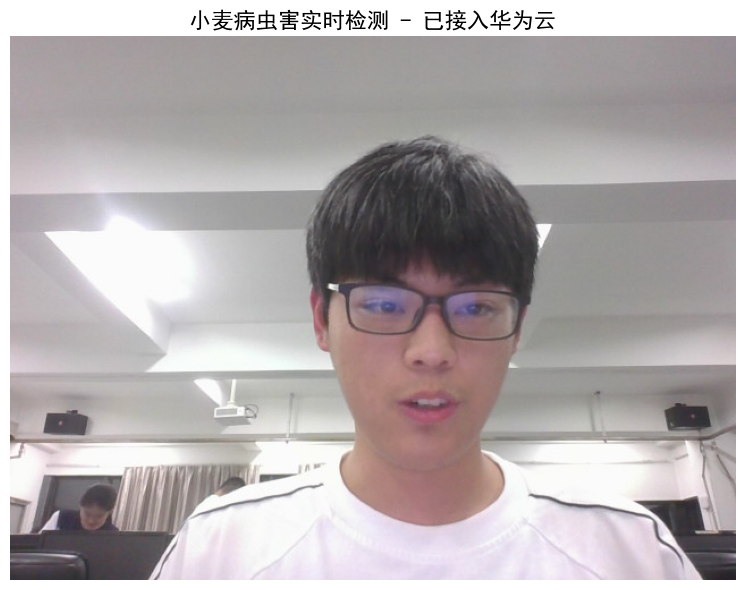


⚠️ 与云端断开连接，尝试重连...
已停止检测，与云端连接已关闭


KeyboardInterrupt: 

In [1]:
# 🔥 Jupyter 必须加这一行，才能显示图像
%matplotlib inline

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output
import numpy as np
import time
import json
import ssl
import paho.mqtt.client as mqtt    # 需要 pip install paho-mqtt

# ==================== 强制中文正常显示 ====================
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 6)

# ==================== 华为云 IoT 设备信息（请务必替换成你自己的） ====================
DEVICE_ID      = "6a40e4bdcbb0cf6bb969e1ca_ai-info"   # 设备ID
MQTT_HOST      = "8d1b1f0d1c.st1.iotda-device.cn-north-4.myhuaweicloud.com"  # MQTT接入地址
MQTT_PORT      = 8883                                      # 标准加密端口
DEVICE_KEY     = "7293334726d0b61406b162888f239ed3633484bbea4d5ac40d25a22e5a372695"              # 设备密钥
PROJECT_ID     = "5d65b97f671d46f185a2a44115c41c8d"                        # 项目ID，通常从云端获取

# 上报主题（华为云固定格式）
TOPIC_UP       = f"$oc/devices/{DEVICE_ID}/sys/properties/report"

# ==================== MQTT 连接与回调 ====================
client = mqtt.Client(client_id=DEVICE_ID)
client.username_pw_set(DEVICE_ID, DEVICE_KEY)  # 设备ID为用户名，密钥为密码
client.tls_set(ca_certs=None, certfile=None, keyfile=None,
               cert_reqs=ssl.CERT_REQUIRED,
               tls_version=ssl.PROTOCOL_TLSv1_2)

def on_connect(client, userdata, flags, rc):
    if rc == 0:
        print("✅ 已连接华为云 IoT")
    else:
        print(f"❌ 连接失败，返回码：{rc}")

def on_disconnect(client, userdata, rc):
    print("⚠️ 与云端断开连接，尝试重连...")
    client.reconnect()

client.on_connect = on_connect
client.on_disconnect = on_disconnect
client.connect(MQTT_HOST, MQTT_PORT, keepalive=60)
client.loop_start()          # 后台持续处理网络心跳

# ==================== 模型路径 ====================
model_path = r'D:\微信QQ\FireDetection\runs\detect\runs\detect\xiaomai_model\weights\best.pt'
model = YOLO(model_path, task='detect')

# ==================== 打开摄像头 ====================
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("摄像头打开失败")
    exit()

print("摄像头已启动 → 按 q 键停止")

# ==================== 辅助函数：将检测结果打包成云平台需要的JSON ====================
def build_payload(results):
    """从 YOLO results 中提取信息，构造华为云属性上报 JSON"""
    objs = []
    for box in results[0].boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        class_name = model.names[cls_id]
        objs.append({
            "类别": class_name,
            "置信度": round(conf, 2),
            "位置": [round(x, 2) for x in box.xyxy[0].tolist()]  # 可选
        })
    return {
        "services": [
            {
                "service_id": "wheat_detection",   # 需与云平台定义的服务ID一致
                "properties": {
                    "检测目标数量": len(objs),
                    "最高置信度": max([o["置信度"] for o in objs]) if objs else 0,
                    "所有目标": objs,
                    "时间戳": time.time()
                }
            }
        ]
    }

last_upload_time = 0
UPLOAD_INTERVAL = 3   # 每3秒上报一次，避免过于频繁

# ==================== Jupyter 实时显示循环 ====================
try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("读取失败")
            break

        # YOLO 检测
        results = model(frame)
        frame_det = results[0].plot()

        # 每隔 UPLOAD_INTERVAL 秒上报一次到华为云
        current_time = time.time()
        if current_time - last_upload_time >= UPLOAD_INTERVAL:
            payload = build_payload(results)
            # 发送 JSON 字符串到云端
            client.publish(TOPIC_UP, json.dumps(payload, ensure_ascii=False), qos=1)
            print(f"📡 上报云端：{json.dumps(payload, ensure_ascii=False, indent=2)}")
            last_upload_time = current_time

        # BGR → RGB（matplotlib 必须转）
        frame_rgb = cv2.cvtColor(frame_det, cv2.COLOR_BGR2RGB)

        # 强制刷新 matplotlib 显示
        clear_output(wait=True)
        plt.imshow(frame_rgb)
        plt.title("小麦病虫害实时检测 - 已接入华为云", fontsize=16)
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        # 按 q 退出
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

finally:
    # 释放资源
    cap.release()
    cv2.destroyAllWindows()
    client.loop_stop()       # 停止 MQTT 心跳
    client.disconnect()      # 断开连接
    print("已停止检测，与云端连接已关闭")